In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
notional_value = 10000000
maturity = 5
fixed_rate = 0.04
payment_frequency = 2
position = "Receive_Fixed"

In [3]:
#Creating Yield Data

curve_data = pd.DataFrame({
    "Tenor" : [0.5,1,2,3,4,5],
    "Rate" : [0.0480,0.0460,0.0430,0.0410,0.0395,0.0390]
} , index=range(1,7))

curve_data

,Tenor,Rate
1,0.5,0.0480
2,1.0,0.0460
3,2.0,0.0430
4,3.0,0.0410
5,4.0,0.0395
6,5.0,0.0390


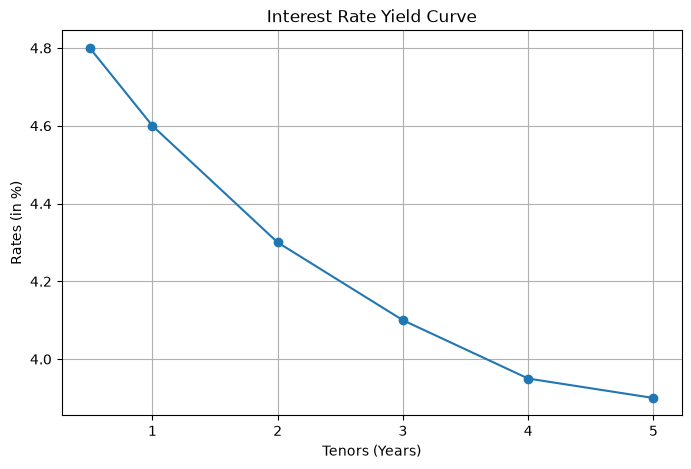

In [4]:
plt.figure(figsize=(8,5))

plt.plot(
    curve_data["Tenor"],
    curve_data["Rate"] *100,
    marker = "o"
)

plt.xlabel("Tenors (Years)")
plt.ylabel("Rates (in %)")
plt.title ("Interest Rate Yield Curve")
plt.grid(True)

plt.show()

In [5]:
#Calculating Discount Rate Factor

curve_data["Discount_Factor"] = (
    1 / (1+curve_data["Rate"]) ** curve_data["Tenor"]
)

In [6]:
#Create Swap Schedule

payment_dates = np.arange(
    0.5,
    maturity + 0.5,
    0.50
)
print(payment_dates)
    

[0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


In [7]:
rate_interpolator = interp1d(
    curve_data["Tenor"],
    curve_data['Rate'],
    kind = "linear",
)

In [8]:
payment_rates = rate_interpolator(payment_dates)
payment_rates

array([0.048  , 0.046  , 0.0445 , 0.043  , 0.042  , 0.041  , 0.04025,
       0.0395 , 0.03925, 0.039  ])

In [9]:
# Create New DATAFRAME

swap_schedule = pd.DataFrame ({
    "Times" : payment_dates,
    "Rates" : payment_rates
}, index = range(1,11))


In [10]:
#Calculate discount_factor for each payment dates

swap_schedule["Discount_Factors "] = ((
    1/ (1 + swap_schedule["Rates"]) ** swap_schedule["Times"]
       ))
swap_schedule

,Times,Rates,Discount_Factors
1,0.5,0.04800,0.976831
2,1.0,0.04600,0.956023
3,1.5,0.04450,0.936779
4,2.0,0.04300,0.919245
5,2.5,0.04200,0.902258
6,3.0,0.04100,0.886437
7,3.5,0.04025,0.871000
8,4.0,0.03950,0.856450
9,4.5,0.03925,0.840930
10,5.0,0.03900,0.825890


In [11]:
#Calculating Fixed Leg Cashflow

accrual_factor = 0.5

swap_schedule["Fixed_cash_flow"] = (notional_value * fixed_rate * accrual_factor)
swap_schedule["Fixed_cash_flow"]

1     200000.0
2     200000.0
3     200000.0
4     200000.0
5     200000.0
6     200000.0
7     200000.0
8     200000.0
9     200000.0
10    200000.0
Name: Fixed_cash_flow, dtype: float64

In [12]:
#Calculating PV of Fixed cashflow

swap_schedule["PV_fixed_cash_flow"] = (
    swap_schedule["Fixed_cash_flow"] * swap_schedule["Discount_Factors "]
)
swap_schedule["PV_fixed_cash_flow"]

fixed_leg_pv = swap_schedule["PV_fixed_cash_flow"].sum()

In [13]:
print("Fixed Leg PV:", fixed_leg_pv)

Fixed Leg PV: 1794368.5895580398


In [14]:
#Calculating Forwards Rates

swap_schedule["Previous_DF"] = (
    swap_schedule["Discount_Factors "].shift(1)
)

swap_schedule.loc[1, "Previous_DF"] = 1

swap_schedule["Forward_Rates"] = (
    (
    swap_schedule["Previous_DF"]
    /swap_schedule["Discount_Factors "]
    )-1
) / accrual_factor

swap_schedule["Forward_Rates"]

1     0.047437
2     0.043530
3     0.041084
4     0.038149
5     0.037655
6     0.035696
7     0.035447
8     0.033977
9     0.036912
10    0.036421
Name: Forward_Rates, dtype: float64

In [15]:
swap_schedule[
    [
        "Times",
        "Rates",
        "Discount_Factors ",
        "Forward_Rates"
    ]
]

,Times,Rates,Discount_Factors,Forward_Rates
1,0.5,0.04800,0.976831,0.047437
2,1.0,0.04600,0.956023,0.043530
3,1.5,0.04450,0.936779,0.041084
4,2.0,0.04300,0.919245,0.038149
5,2.5,0.04200,0.902258,0.037655
6,3.0,0.04100,0.886437,0.035696
7,3.5,0.04025,0.871000,0.035447
8,4.0,0.03950,0.856450,0.033977
9,4.5,0.03925,0.840930,0.036912
10,5.0,0.03900,0.825890,0.036421


In [16]:
#Calculating Floating Rate cashflow

# Formula  = Notional * Forward Rates * Accural_Factor

swap_schedule["Floating_cash_flow"] = (
    notional_value * swap_schedule["Forward_Rates"] * accrual_factor
)

swap_schedule["PV_floating_cash_flow"] = (
    swap_schedule["Floating_cash_flow"] * swap_schedule["Discount_Factors "]
)

PV_floating_cash_flow = swap_schedule["PV_floating_cash_flow"].sum()
PV_floating_cash_flow

print("Floating Leg PV", PV_floating_cash_flow)

Floating Leg PV 1741098.9622137556


In [17]:
#Calculting SWAP PV

swap_PV = swap_schedule["PV_fixed_cash_flow"] - swap_schedule["PV_floating_cash_flow"]

print("Swap_PV:")
print(swap_PV.to_string())

swap_PV.sum()

Swap_PV:
1    -36325.519152
2    -16874.280140
3     -5079.530429
4      8507.272134
5     10578.514558
6     19076.879626
7     19827.402563
8     25794.057180
9     12985.861102
10    14778.969903


np.float64(53269.627344284236)

In [18]:
#Calculating Par Swap Rate; i.e PVswap = 0

#Formula: 

# par = PVfloating/ Notional * sum of discountfactor* accrual interest

#annuity = discount factor * accrual interest

annuity = (
    swap_schedule["Discount_Factors "] * accrual_factor
).sum()

swap_par_PV = (
    PV_floating_cash_flow / (notional_value * annuity)
)

print( "Par Swap Rate :", swap_par_PV)
print( "Par Swap Rate % :", swap_par_PV*100) 

swap_par_PV

Par Swap Rate : 0.03881251538498219
Par Swap Rate % : 3.881251538498219


np.float64(0.03881251538498219)

In [19]:
#Model Validation

par_fixed_calculation = (
    notional_value *
    swap_par_PV *
    accrual_factor
)

par_fixed_pv = (
    par_fixed_calculation * 
    swap_schedule["Discount_Factors "]
).sum()

print("Par Fixed PV:",par_fixed_pv)
print("Par Fixed Calculation",par_fixed_calculation)
par_swap_pv = par_fixed_pv - PV_floating_cash_flow

print("Par Swap PV:",par_swap_pv)


Par Fixed PV: 1741098.9622137556
Par Fixed Calculation 194062.57692491094
Par Swap PV: 0.0


In [20]:
#Notional Scaling Test

def calculate_swap_pv (notional_value, fixed_rate, schedule):

    fixed_cf = (
        notional_value*
        fixed_rate*
        accrual_factor
    )

    fixed_pv = (
        fixed_cf *
        schedule["Discount_Factors "]
    ).sum()

    floating_cf = (
        notional_value *
        schedule["Forward_Rates"] *
        accrual_factor
    )
    floating_pv = (
        floating_cf*
        schedule["Discount_Factors "]
    ).sum()

    return fixed_pv - floating_pv
        

In [21]:
pv_10m = calculate_swap_pv(
    10_000_000,
    fixed_rate,
    swap_schedule
)

pv_20m = calculate_swap_pv(
    20_000_000,
    fixed_rate,
    swap_schedule
)

print("10M PV:", pv_10m)
print("20M PV:", pv_20m)
print("Ratio:", pv_20m / pv_10m)

10M PV: 53269.62734428421
20M PV: 106539.25468856841
Ratio: 2.0


In [22]:
#DV01

def price_with_curve_shift(shift):
    
    shifted_schedule = swap_schedule.copy()

    shifted_schedule["Shifted_Rates"] = (
        shifted_schedule["Rates"] + shift
    )

    shifted_schedule["Shifted_DF"] = (
        1/
        (1 + shifted_schedule["Shifted_Rates"]) ** shifted_schedule["Times"]
    )

    Shifted_fixed_pv = (
        notional_value*
        fixed_rate *
        shifted_schedule["Shifted_DF"]*
        accrual_factor
    ).sum()

    Shifted_previous_DF = (
        shifted_schedule["Shifted_DF"].shift(1)
    )
    Shifted_previous_DF.iloc[0] = 1

    Shifted_forward_rates =  (
        ((Shifted_previous_DF/shifted_schedule["Shifted_DF"]) -1 )/
        accrual_factor
    )

    Shifted_float_CF = (
        notional_value * 
        Shifted_forward_rates*
        accrual_factor
    )

    Shifted_float_pv = (
        Shifted_float_CF * 
        shifted_schedule["Shifted_DF"]
    ).sum()

    return Shifted_fixed_pv - Shifted_float_pv

In [23]:
#Calculate DV01

one_bps = 0.0001
pv_up = price_with_curve_shift(one_bps)
pv_down = price_with_curve_shift(- one_bps)

dv01 = (pv_down - pv_up)/ 2

print("Base PV:", swap_PV.sum())
print("PV +1bp:", pv_up)
print("PV -1bp:", pv_down)
print("DV01:", dv01)

Base PV: 53269.627344284236
PV +1bp: 48835.4420688306
PV -1bp: 57706.30486290483
DV01: 4435.431397037115


In [24]:
#Stress Testing

shocks = [
    -0.02,
    -0.01,
    -0.005,
    0,
    0.005,
    0.01,
    0.02
]

stress_results =[]

for shock in shocks:

    pv = price_with_curve_shift(shock)

    stress_results.append({
        "Shock" : shock,
        "Swap_PV" : pv,
        "Change" : pv-swap_PV.sum()

    })

stress_df = pd.DataFrame(stress_results)

print(stress_df)

   Shock        Swap_PV        Change
0 -0.020  992496.173406  9.392265e+05
1 -0.010  509555.335589  4.562857e+05
2 -0.005  278191.321849  2.249217e+05
3  0.000   53269.627344 -2.910383e-11
4  0.005 -165420.800830 -2.186904e+05
5  0.010 -378083.109419 -4.313527e+05
6  0.020 -786098.403563 -8.393680e+05


In [25]:
stress_df["Shock_bps"] = (
    stress_df["Shock"] * 10000
)

stress_df

,Shock,Swap_PV,Change,Shock_bps
0,-0.020,992496.173406,9.392265e+05,-200.0
1,-0.010,509555.335589,4.562857e+05,-100.0
2,-0.005,278191.321849,2.249217e+05,-50.0
3,0.000,53269.627344,-2.910383e-11,0.0
4,0.005,-165420.800830,-2.186904e+05,50.0
5,0.010,-378083.109419,-4.313527e+05,100.0
6,0.020,-786098.403563,-8.393680e+05,200.0


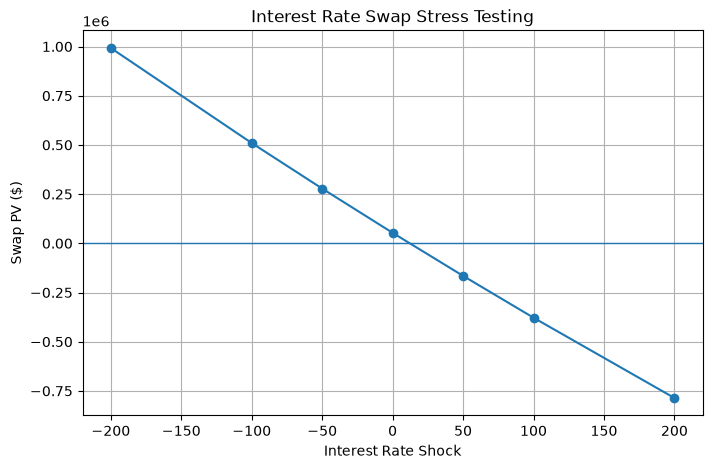

In [26]:
#Plot Stress Test

plt.figure(figsize=(8,5))

plt.plot(
    stress_df["Shock_bps"],
    stress_df["Swap_PV"],
    marker= "o"
)

plt.axhline(0, linewidth = 1)
plt.xlabel("Interest Rate Shock")
plt.ylabel("Swap PV ($)")
plt.title("Interest Rate Swap Stress Testing")

plt.grid(True)
plt.show()

In [27]:
#Independent Benchmark

df_0 = 1

df_maturity = swap_schedule.iloc[-1]["Discount_Factors "]

benchmark_floating_pv = (
    notional_value *
    (df_0 - df_maturity)
)

print("Model Floating PV:", PV_floating_cash_flow)
print("Benchmark Floating PV:", benchmark_floating_pv)

difference = (
    PV_floating_cash_flow -
    benchmark_floating_pv
)

print("Difference:", difference)

tolerance = 0.01  # $0.01

difference = (
    PV_floating_cash_flow - benchmark_floating_pv
)

if abs(difference) < tolerance:
    result = "PASS"
else:
    result = "FAIL"

print("Difference:", difference)
print("Validation Result:", result)

Model Floating PV: 1741098.9622137556
Benchmark Floating PV: 1741098.9622137574
Difference: -1.862645149230957e-09
Difference: -1.862645149230957e-09
Validation Result: PASS


In [28]:
# Validation Summary - Dynamic Checks


# 1. Par Swap Rate Test
par_test = np.isclose(
    par_swap_pv, 0.0, atol=0.01
)

# 2. Notional Scaling Test
scaling_test = np.isclose(
    pv_20m, 2 * pv_10m,
    rtol=1e-9, atol=1e-6
)

# 3. Independent Floating-Leg Benchmark
benchmark_test = np.isclose(
    PV_floating_cash_flow,
    benchmark_floating_pv,
    atol=tolerance, rtol=0
)

# 4. DV01 Direction Check
base_pv = swap_PV.sum()

dv01_test = (
    pv_down > base_pv > pv_up
    and dv01 > 0
)

# 5. Zero-Shock Stress Test
zero_shock_change = stress_df.loc[
    np.isclose(stress_df["Shock"], 0),
    "Change"
].iloc[0]

zero_shock_test = np.isclose(
    zero_shock_change, 0.0, atol=0.01
)

# Generate validation results dynamically
tests = {
    "Par Rate Test": par_test,
    "Notional Scaling": scaling_test,
    "Independent Benchmark": benchmark_test,
    "DV01 Direction Check": dv01_test,
    "Zero-Shock Stress Test": zero_shock_test
}

validation_results = pd.DataFrame({
    "Validation_Test": list(tests.keys()),
    "Result": [
        "PASS" if passed else "FAIL"
        for passed in tests.values()
    ]
})

display(validation_results)

,Validation_Test,Result
0,Par Rate Test,PASS
1,Notional Scaling,PASS
2,Independent Benchmark,PASS
3,DV01 Direction Check,PASS
4,Zero-Shock Stress Test,PASS
